# Grid refinement in a restart chain

Three runs of the same quartz column, all reaching 5000 yr on a 400-cell grid or its equivalent:

| run | what it does | wall clock |
|---|---|---|
| `quartz_fine_reference.yaml` | cold start, 400 cells throughout | 56 s |
| `quartz_refine_chain.yaml` | 100 cells to 4500 yr, then `refine: 4` for the last 500 yr | 21 s |
| `quartz_graded_chain.yaml` | 100 cells, then 100 graded cells concentrated at the inlet | 17 s |

The question this notebook answers is not whether the chain is faster — it plainly is — but
**where the answer it gives differs from the cold start, and why**.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

style_path = Path.home() / 'Python' / 'mpl_styles' / 'publication.mplstyle'
if style_path.exists():
    plt.style.use(str(style_path))

# Wall clock as measured on the machine that produced the committed netCDF files. Rerunning
# will not reproduce these exactly, but the ratio between them is the point.
WALL_CLOCK = {'400 cells,\ncold start': 56, 'refine: 4\nchain': 21, 'graded\nchain': 17}


def profile(run, group, variable, time):
    """One stage's spatial profile, with the cells that stage did not cover dropped.

    A grid-varying chain reports every stage on one X coordinate and leaves NaN where a stage
    had no cell, so a stage's own profile is the non-NaN part of its time slice.
    """
    data = xr.open_dataset(f'{run}.nc', group=group)[variable]
    data = data.isel(file_num=0, Y=0, Z=0).sel(time=time)
    covered = ~np.isnan(data.values)

    return data.X.values[covered], data.values[covered]

## What is in the files

The chain writes both stages into one `results.nc`. The coarse stage's cells are placed at their
nearest position on the fine grid and everything else is NaN, so nothing is invented and the coarse
spin-up is still there to look at.

In [2]:
for run in ('quartz_fine_reference', 'quartz_refine_chain', 'quartz_graded_chain'):
    dataset = xr.open_dataset(f'{run}.nc', group='totcon')
    series = dataset['SiO2(aq)'].isel(file_num=0, Y=0, Z=0)
    covered = [int(np.sum(~np.isnan(series.isel(time=i).values))) for i in range(dataset.sizes['time'])]
    print(f'{run:24s} X = {dataset.sizes["X"]:3d}   '
          f'times = {[float(t) for t in dataset.time.values]}   cells covered = {covered}')

quartz_fine_reference    X = 400   times = [5000.0]   cells covered = [400]
quartz_refine_chain      X = 400   times = [4500.0, 5000.0]   cells covered = [100, 400]
quartz_graded_chain      X = 200   times = [4500.0, 5000.0]   cells covered = [100, 100]


The graded chain keeps 200 X positions rather than 100. Its two grids do not nest — the second is
four times finer over the first 20 m and four times *coarser* over the remaining 80 — so neither can
hold the other's cells without collision, and the union is kept instead. That is reported when it
happens.

In [3]:
x_ref, si_ref = profile('quartz_fine_reference', 'totcon', 'SiO2(aq)', 5000.0)
x_chain, si_chain = profile('quartz_refine_chain', 'totcon', 'SiO2(aq)', 5000.0)
x_coarse, si_coarse = profile('quartz_refine_chain', 'totcon', 'SiO2(aq)', 4500.0)
x_graded, si_graded = profile('quartz_graded_chain', 'totcon', 'SiO2(aq)', 5000.0)

scale = np.max(si_ref)
for name, x, si in (('refine chain', x_chain, si_chain),
                    ('graded chain', x_graded, si_graded),
                    ('coarse stage alone', x_coarse, si_coarse)):
    error = np.max(np.abs(si - np.interp(x, x_ref, si_ref))) / scale
    print(f'{name:20s} max departure from the cold start: {error:6.2%}')

refine chain         max departure from the cold start:  3.68%
graded chain         max departure from the cold start:  3.68%
coarse stage alone   max departure from the cold start: 17.85%


Refining is worth it: the coarse stage is 18% away from the cold-start answer and both chains close
that to under 4%. The remaining 4% is the interesting part.

In [4]:
q_ref = profile('quartz_fine_reference', 'volume', 'Quartztope', 5000.0)
q_chain = profile('quartz_refine_chain', 'volume', 'Quartztope', 5000.0)

print(f'quartz volume fraction in the first cell — cold start {q_ref[1][0]:.4f}, '
      f'chain {q_chain[1][0]:.4f}')
print(f'fluid SiO2 in the first cell            — cold start {si_ref[0]:.3e}, '
      f'chain {si_chain[0]:.3e}')

quartz volume fraction in the first cell — cold start 0.0526, chain 0.0259
fluid SiO2 in the first cell            — cold start 5.518e-06, chain 3.850e-06


There is the answer. At 100 m/yr the column flushes in 0.1 yr, so 500 yr on the fine grid relaxes
the *fluid* completely — and yet the profiles still differ at the inlet, because the **mineral**
field does not relax. The coarse stage spent 4500 yr dissolving quartz through cells 1 m wide,
which over-dissolves the inlet where the real gradient is sharp, and the fine stage inherits that
history. Refining does not undo it.

That is the rule for when a chain is safe: the coarse stage must be genuine spin-up for the slow
variables too. Here it is not, and the example is more useful for showing that than it would be if
the numbers had simply agreed.

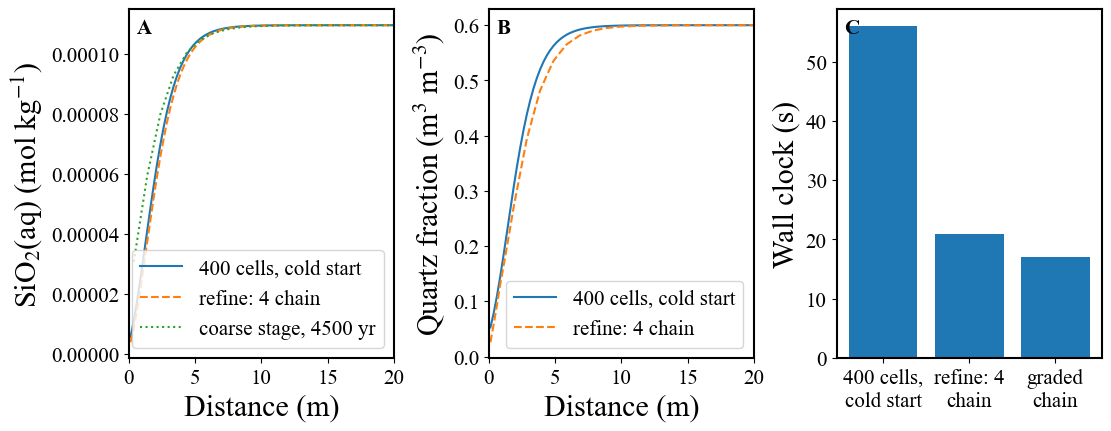

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4.2), constrained_layout=True)

inlet = 20.0

ax = axes[0]
ax.plot(x_ref, si_ref, label='400 cells, cold start')
ax.plot(x_chain, si_chain, linestyle='--', label='refine: 4 chain')
ax.plot(x_coarse, si_coarse, linestyle=':', label='coarse stage, 4500 yr')
ax.set_xlim(0, inlet)
ax.set_xlabel('Distance (m)')
ax.set_ylabel('SiO$_2$(aq) (mol kg$^{-1}$)')
ax.legend(loc='lower right')

ax = axes[1]
ax.plot(q_ref[0], q_ref[1], label='400 cells, cold start')
ax.plot(q_chain[0], q_chain[1], linestyle='--', label='refine: 4 chain')
ax.set_xlim(0, inlet)
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Quartz fraction (m$^3$ m$^{-3}$)')
ax.legend(loc='lower right')

ax = axes[2]
ax.bar(list(WALL_CLOCK), list(WALL_CLOCK.values()))
ax.set_ylabel('Wall clock (s)')

for ax, letter in zip(axes, 'ABC'):
    ax.text(0.03, 0.97, letter, transform=ax.transAxes, fontweight='bold',
            va='top', ha='left')

fig.savefig('grid_refinement_chain.png', dpi=200)

**A** — the fluid profile at the inlet. The chain sits on the cold-start curve; the coarse stage it
started from does not.

**B** — the quartz volume fraction, where the chain and the cold start disagree. This is the coarse
stage's 4500 yr of mineral dissolution, inherited through the restart and not undone by refining.

**C** — what it cost. The chain reaches a 400-cell fluid answer for 38% of the cold-start time, and
the graded chain for 30%.